# Exploratory Data Analysis

## Purpose

Now that we have built the database [here](https://github.com/dcnguyen060899/su_cpsc5071_group_project_sad_sravya_anushka_duy/blob/main/code/database_pipeline.ipynb) and verified its integrity [here](https://drive.google.com/file/d/1OSIwjfpD2X4gO4Ed4qCL-0lqwpepmJz7/view), we can begin exploring the **analysis-ready dataset**, you can access it from VIEW mysql on your LOCAL database from after you ran the [database pipeline script](https://github.com/dcnguyen060899/su_cpsc5071_group_project_sad_sravya_anushka_duy/blob/main/code/database_pipeline.ipynb). Remember to use **LOCAL** because Seattle U database won't let you create database! It's the flat, joined view of all four tables. The goal of this notebook is to understand the distributions, relationships, and potential issues in our data *before* building any predictive models.

**In this notebook, what we want to learn:**
1. How is our target variable (`total_disasters`) distributed? Is it skewed? Are there outliers?
2. What do our predictor variables (demographics, housing costs) look like? Are they normally distributed or do they need transformation?
3. Are there meaningful correlations between county characteristics and disaster frequency?
4. How much missing data do we have, and which counties are affected?
5. Should we engineer new features (e.g., poverty *rate* instead of poverty *count*)?

These answers will directly inform our modeling strategy, such as what algorithms to use, whether we need to handle class imbalance, and which features to prioritize.

## First, We Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text


# plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Locally please load from MySQL Workbench or MySQL Docker container using SQLAlchemy and mysql-connector-python
# PLEASE: remember to use password with your own MySQL password and not mine!
config = {
    'host': '', # this is not your host, please use your own host for your local MySQL instance (e.g., localhost or 127.0.0.1)
    'user': '', # this is not your username, please use your own username for your local MySQL instance (e.g., root or admin or whatever you namded your MySQL user)
    'password': '', # this is not your password, please use your own password for your local MySQL instance
    'port': , # this is not your port, please use your own port for your local MySQL instance (e.g., 3306 or whatever you mapped in your Docker container)
    'database': 'disaster_impact_db' # this is our database name, you can keep it the same or change it in the database pipeline
     # if you want but make sure to update it here and in your MySQL instance accordingly
}

engine = create_engine(
    f"mysql+mysqlconnector://{config['user']}:{config['password']}@{config['host']}:{config['port']}/{config['database']}"
)

# print out some basic info to confirm connection and data access to your local machine's MySQL Docker container
# it a good practice to run some basic queries to confirm the connection 
# and data access before running more complex queries or loading large datasets into pandas
with engine.connect() as conn: 
    result = conn.execute(text("SELECT VERSION()"))
    print(f"MySQL Version: {result.scalar()}")

    result = conn.execute(text("SELECT DATABASE()"))
    print(f"Connected to DB: {result.scalar()}")

    result = conn.execute(text("SELECT COUNT(*) FROM analysis_ready"))
    print(f"Rows in analysis_ready: {result.scalar()}")

    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]
    print(f"Tables: {tables}")

print("\nConnection successful - running against local MySQL Docker container. \n")

df = pd.read_sql('SELECT * FROM analysis_ready', engine)
engine.dispose() # it is a good pracetice to dispose the engine after use to free up resources

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

MySQL Version: 8.0.44
Connected to DB: disaster_impact_db
Rows in analysis_ready: 3292
Tables: ['analysis_ready', 'county', 'county_disaster_summary', 'demographics', 'disasters', 'housing_costs']

Connection successful - running against local MySQL Docker container. 

Shape: (3292, 17)
Columns: ['fips', 'county_name', 'state_abbr', 'total_disasters', 'ia_count', 'pa_count', 'total_population', 'median_household_income', 'poverty_count', 'unemployment_count', 'labor_force_count', 'fmr_0', 'fmr_1', 'fmr_2', 'fmr_3', 'fmr_4', 'metro']


,fips,county_name,state_abbr,total_disasters,ia_count,pa_count,total_population,median_household_income,poverty_count,unemployment_count,labor_force_count,fmr_0,fmr_1,fmr_2,fmr_3,fmr_4,metro
0,01000,Unknown,AL,7,0.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01001,"Autauga County, Alabama",AL,6,0.0,6.0,58761.0,68315.0,6630.0,752.0,27163.0,848.0,888.0,1055.0,1345.0,1665.0,1.0
2,01003,"Baldwin County, Alabama",AL,5,0.0,5.0,233420.0,71039.0,23445.0,3825.0,111079.0,972.0,1043.0,1244.0,1550.0,1975.0,1.0
3,01005,"Barbour County, Alabama",AL,7,0.0,7.0,24877.0,39712.0,5280.0,516.0,8968.0,587.0,648.0,772.0,996.0,1027.0,0.0
4,01007,"Bibb County, Alabama",AL,5,0.0,5.0,22251.0,50669.0,4297.0,786.0,9028.0,998.0,1144.0,1267.0,1583.0,1791.0,1.0



## Overview Our Dataset

In [37]:
print('Data types:')
print(df.dtypes)
print(f'\nTotal rows: {len(df)}')
print(f'Total columns: {len(df.columns)}')

Data types:
fips                        object
county_name                 object
state_abbr                  object
total_disasters              int64
ia_count                   float64
pa_count                   float64
total_population           float64
median_household_income    float64
poverty_count              float64
unemployment_count         float64
labor_force_count          float64
fmr_0                      float64
fmr_1                      float64
fmr_2                      float64
fmr_3                      float64
fmr_4                      float64
metro                      float64
dtype: object

Total rows: 3292
Total columns: 17


In [38]:
# missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'null_count': missing, 'null_pct': missing_pct})
print('Missing values per column:')
print(missing_df[missing_df['null_count'] > 0].sort_values('null_count', ascending=False))
print(f'\nRows with complete data across all columns: {df.dropna().shape[0]} / {len(df)}')

Missing values per column:
                         null_count  null_pct
median_household_income          71       2.2
total_population                 70       2.1
poverty_count                    70       2.1
unemployment_count               70       2.1
labor_force_count                70       2.1
fmr_0                            64       1.9
fmr_1                            64       1.9
fmr_2                            64       1.9
fmr_3                            64       1.9
fmr_4                            64       1.9
metro                            64       1.9
state_abbr                        9       0.3

Rows with complete data across all columns: 3212 / 3292


### Note: Two Ways of Counting Missing Data

There are two different missing value counts in this project and they measure different things.

**Database-level NULLs (from the LEFT JOIN in `analysis_ready`)**
The database reports NULLs *per column* independently. A county missing Census data
contributes 1 NULL to `total_population`, 1 to `poverty_count`, 1 to `unemployment_count`,
and so on for each column counted separately. This is why the verification report shows
70 NULL demographics and 64 NULL housing costs as distinct numbers.

**Modeling-level dropped rows (listwise deletion)**
When preparing data for modeling, a row is only usable if *every* column has a value.
`df.dropna()` drops any row with at least one NULL anywhere. Because ~55 counties are
missing *both* Census and HUD data, their NULLs overlap due to the union of all incomplete
rows is 80, not 71 + 64 = 135.

Note that the 55 counties missing is calculated by using what we learned from Probability Theory for Data Science course this quarter at Seattle University, if you take |A ∪ B| = |A| + |B| - |A ∩ B|, this is the inclusion exclusion principle, so that means you get the overlap of:
$$80 = 71 + 64 - overlap$$
$$overlap = 71 + 64 - 80 = 55$$

**The relationship:**
- Database view: 71 NULL Census rows (including 1 income-suppressed county) + 64 NULL HUD rows (counted per column, with overlap)
- Modeling dataset: 80 rows dropped (counted per row, union of all nulls), that is around **3,212 complete rows**

Bottom line is that the database tells you *which columns* have gaps; the modeling drop tells you
*how many rows* you lose when you act on those gaps.

In [39]:
# quick double check our probability math is right for the nulls in the census and hud data
census_null = df['total_population'].isna()
hud_null = df['fmr_0'].isna()
print((census_null & hud_null).sum())  # should be ~54

55


### Characterizing the Dropped Counties

Before proceeding with analysis on complete-data rows, we profile the counties excluded from modeling due to missing demographic or housing data. This is standard practice in applied research: if dropped counties differ systematically from retained ones, that difference is a limitation that must be acknowledged. If they are similar, we can proceed with greater confidence that listwise deletion does not introduce meaningful selection bias into our estimates.



Total counties  : 3,292
Dropped (any NULL): 80  (2.4%)
Kept (complete)   : 3,212  (97.6%)

Null pattern in dropped counties:
median_household_income    71
total_population           70
poverty_count              70
unemployment_count         70
labor_force_count          70
fmr_0                      64
fmr_1                      64
fmr_2                      64
fmr_3                      64
fmr_4                      64
metro                      64
state_abbr                  9

 Disaster Count: Dropped vs. Kept
       dropped     kept
count    80.00  3212.00
mean     11.51     5.54
std      17.81     5.44
min       0.00     0.00
25%       2.00     3.00
50%       6.00     4.00
75%       9.50     7.00
max      90.00   149.00


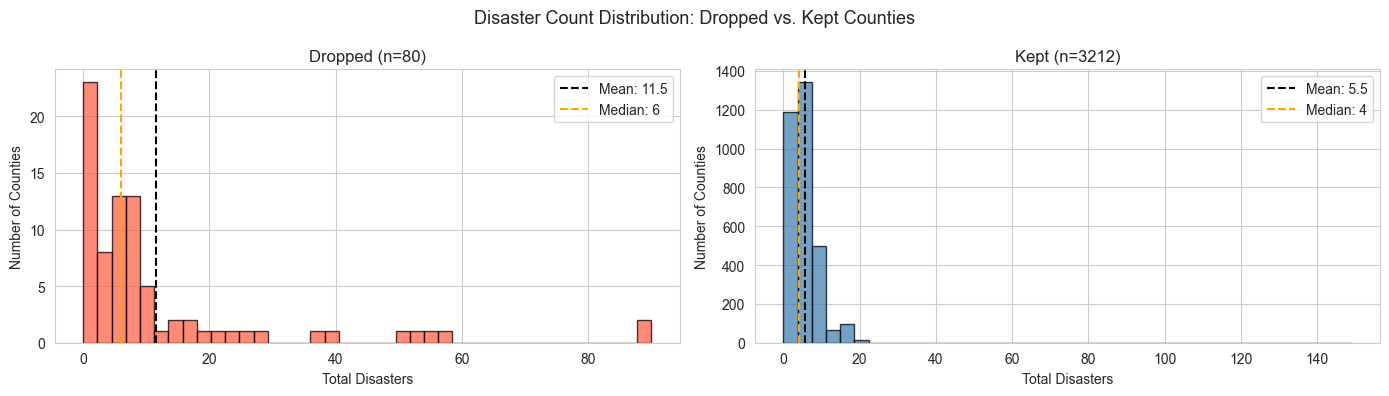


 State Concentration of Dropped Counties (with missing Census/HUD data)
state_abbr  n_dropped
        CT          9
        AS          7
        MP          6
        AK          5
        VI          3
        VA          2
        TX          2
        SD          2
        AZ          1
        OK          1
        NE          1
        NJ          1
        NM          1
        NV          1
        NY          1


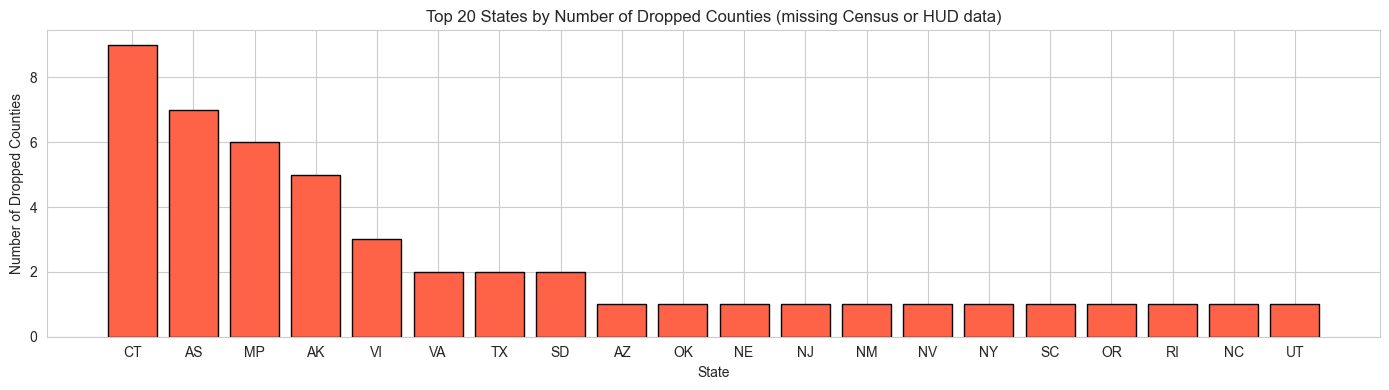


 Metro Flag: Dropped vs. Kept
           dropped_pct  kept_pct
metro                           
Non-Metro         50.0      61.3
Metro             50.0      38.7

 FEMA Program Activation in Dropped Counties
       ia_count  pa_count  total_disasters
count      80.0      80.0             80.0
mean        0.0      10.8             11.5
std         0.0      17.2             17.8
min         0.0       0.0              0.0
25%         0.0       2.0              2.0
50%         0.0       5.0              6.0
75%         0.0       8.2              9.5
max         0.0      90.0             90.0


In [40]:
# Partition into dropped vs. kept counties based on presence of any NULL values
# remember to make a copy() so that we can modified the dropped/kept subsets later without affecting the original df
dropped = df[df.isnull().any(axis=1)].copy()
kept    = df[df.notnull().all(axis=1)].copy()

print(f'Total counties  : {len(df):,}')
print(f'Dropped (any NULL): {len(dropped):,}  ({len(dropped)/len(df)*100:.1f}%)')
print(f'Kept (complete)   : {len(kept):,}  ({len(kept)/len(df)*100:.1f}%)')

# let's take a look at which columns drive the NULLs?
print('\nNull pattern in dropped counties:')
null_pattern = dropped.isnull().sum()
print(null_pattern[null_pattern > 0].sort_values(ascending=False).to_string())

# Disaster frequency comparison
print('\n Disaster Count: Dropped vs. Kept')
compare = pd.DataFrame({
    'dropped': dropped['total_disasters'].describe().round(2),
    'kept':    kept['total_disasters'].describe().round(2)
})
print(compare.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, grp, label, color in zip(
    axes,
    [dropped, kept],
    ['Dropped (n={})'.format(len(dropped)), 'Kept (n={})'.format(len(kept))],
    ['tomato', 'steelblue']
):
    ax.hist(grp['total_disasters'], bins=40, edgecolor='black', alpha=0.75, color=color)
    ax.axvline(grp['total_disasters'].mean(),   color='black',  linestyle='--', label=f"Mean: {grp['total_disasters'].mean():.1f}")
    ax.axvline(grp['total_disasters'].median(), color='orange', linestyle='--', label=f"Median: {grp['total_disasters'].median():.0f}")
    ax.set_title(label)
    ax.set_xlabel('Total Disasters')
    ax.set_ylabel('Number of Counties')
    ax.legend()
plt.suptitle('Disaster Count Distribution: Dropped vs. Kept Counties', fontsize=13)
plt.tight_layout()
plt.show()

# geographic concentration of those counties with missing data
print('\n State Concentration of Dropped Counties (with missing Census/HUD data)')
state_dropped = (
    dropped.groupby('state_abbr')
           .size()
           .reset_index(name='n_dropped')
           .sort_values('n_dropped', ascending=False)
)
print(state_dropped.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 4))
top_states = state_dropped.head(20)
ax.bar(top_states['state_abbr'], top_states['n_dropped'], color='tomato', edgecolor='black')
ax.set_xlabel('State')
ax.set_ylabel('Number of Dropped Counties')
ax.set_title('Top 20 States by Number of Dropped Counties (missing Census or HUD data)')
plt.tight_layout()
plt.show()

# Metro/rural breakdown
print('\n Metro Flag: Dropped vs. Kept')
metro_compare = pd.DataFrame({
    'dropped_pct': dropped['metro'].value_counts(normalize=True).mul(100).round(1),
    'kept_pct':    kept['metro'].value_counts(normalize=True).mul(100).round(1)
}).rename(index={0: 'Non-Metro', 1: 'Metro'})
print(metro_compare.to_string())

# What disaster types affected dropped counties?
print('\n FEMA Program Activation in Dropped Counties')
program_summary = dropped[['ia_count', 'pa_count', 'total_disasters']].describe().round(1)
print(program_summary.to_string())


Why counties are missing data (null pattern):
The NULLs fall into three distinct buckets originating from our database design. The 70 counties missing all demographic columns are FIPS codes that appear in FEMA disaster records but have no matching row in the Census ACS. Notice that these are real places that experienced federally declared disasters but were not covered by the ACS survey (U.S. Census Bureau, 2023). The 64 counties missing all FMR housing columns similarly appear in FEMA or Census data but were absent from the HUD Fair Market Rent dataset. One additional county has only median_household_income NULL due to Census Bureau suppression (the sentinel value -666666666 our pipeline correctly converted to NULL). Because many counties overlap both gaps, the union of all NULL rows is 80, not 134. Good thing is that these are not data entry errors; they are genuine coverage gaps across three independently maintained federal datasets.

Disaster frequency (FEMA coverage):
The dropped counties are not missing at random with respect to disaster exposure. Dropped counties have a mean of 11.5 disasters and a median of 6, compared to a mean of 5.5 and a median of 4 for kept counties, that is roughly double the disaster frequency. The right tail also extends further (max 90 vs 149, but across only 80 vs 3,212 counties). This means listwise deletion disproportionately removes high-disaster-frequency places. Additionally, every single dropped county has ia_count = 0 with a PA mean of 10.8, indicating these counties received exclusively Public Assistance and no Individual Assistance. This is clearly a structurally distinct FEMA response pattern absent from the 3,212 kept counties.

Geographic concentration:
The coverage gaps are not nationally distributed — they are concentrated in identifiable administrative categories. Connecticut (9 counties) restructured from counties to planning regions in 2022, causing the Census Bureau to retire legacy FIPS codes (09001–09015) and adopt new county-equivalent codes beginning with the 2022 ACS release (U.S. Census Bureau, 2023a; Federal Register, 2022). American Samoa (7), Northern Mariana Islands (6), and the US Virgin Islands (3) are US territories with limited and inconsistent ACS and HUD Fair Market Rent coverage (U.S. Census Bureau, 2023b; HUD, 2023). Alaska (5) uses non-standard county-equivalents — boroughs and census areas — that result in inconsistent FIPS-level matching with HUD Fair Market Rent data (HUD, 2023). The remaining ~15 dropped counties are scattered across VA, TX, SD, AZ, and other states, likely representing tribal lands or independent cities that do not map cleanly to standard county FIPS codes. This is a structured geographic exclusion, not a random sampling gap.


Metro/rural split:
Contrary to the expectation that rural areas would be disproportionately excluded, dropped counties are actually more urban than kept counties because 50% metro among dropped vs. 39% metro among kept. This is explained by Connecticut: its 9 dropped counties include dense urban areas such as Hartford and New Haven. A common concern with missing federal data is that rural or remote areas are disproportionately excluded, which would bias the model toward urban counties. Good news that the data does not support this, as you can see that dropped counties are actually more urban than kept counties (50% vs. 39% metro), driven largely by Connecticut's 9 restructured urban counties (including Hartford and New Haven). The missingness pattern here is administrative, not geographic, and does not systematically skew the retained sample toward either urban or rural areas.


Conclusion on selection bias risk:
Listwise deletion (dropna() from Pandas) is pragmatically necessary given only 2.4% of rows are affected, but it is not statistically neutral (meaning that like if we flipped a coin 3,292 times and randomly lost 80 results then those 80 lost flips wouldn't systematically change our conclusions. That's statistically neutral missingness). The dropped counties are systematically higher-disaster, exclusively PA-activated, and geographically confined to US territories, Alaska frontier areas, and Connecticut's restructured jurisdictions. The 3,212 complete-data counties represent a large and nationally distributed sample, but model conclusions should not be extended to territories, Alaska non-standard jurisdictions, or administratively restructured counties. This is a data infrastructure limitation, thereby three federal datasets do not share uniform geographic coverage. However, its directional effect on the model is known: disaster frequency and the absence of IA activation in these geographies are unrepresented.

In [41]:
# summary statistics for numeric columns
df.describe().round(1)

,total_disasters,ia_count,pa_count,total_population,median_household_income,poverty_count,unemployment_count,labor_force_count,fmr_0,fmr_1,fmr_2,fmr_3,fmr_4,metro
count,3292.0,3292.0,3292.0,3222.0,3221.0,3222.0,3222.0,3222.0,3228.0,3228.0,3228.0,3228.0,3228.0,3228.0
mean,5.7,0.0,5.6,103777.1,62326.9,13001.2,2827.3,52484.2,846.2,909.8,1117.6,1453.7,1674.2,0.4
std,6.1,0.0,6.0,329949.4,17770.6,43264.4,10828.3,173474.7,300.3,321.5,365.7,472.6,564.6,0.5
min,0.0,0.0,0.0,50.0,14525.0,3.0,0.0,36.0,413.0,418.0,475.0,599.0,648.0,0.0
25%,3.0,0.0,3.0,11039.8,51823.0,1526.2,223.0,4748.0,658.0,711.0,907.0,1167.0,1306.0,0.0
50%,4.0,0.0,4.0,25910.0,60461.0,3799.5,589.0,11515.0,737.0,790.0,971.0,1287.5,1499.5,0.0
75%,7.0,0.0,7.0,67370.5,70379.0,9767.8,1705.5,31770.2,922.2,991.2,1215.0,1595.2,1844.0,1.0
max,149.0,0.0,149.0,9936690.0,170463.0,1343978.0,365544.0,5235164.0,3056.0,3221.0,4223.0,5256.0,5605.0,1.0


### Dataset Overview

Okay now that we finsihed data cleaning, here some general insights from our final, cleaned dataset:

**Shape:** 3,292 rows (counties) x 17 columns. Each row is a county with its disaster count, demographic profile, and housing cost profile joined together.


**Key observation from `.describe()`:** Notice the wide range in `total_population` (from tiny rural counties to Los Angeles with ~10 million). This means raw counts like `poverty_count` and `unemployment_count` are not directly comparable across counties. So basically, understand that a county with 1,000 unemployed people out of 10,000 is very different from 1,000 out of 5 million. We will need to compute **rates** (per capita) for meaningful comparisons. It also help later when we regress, the model can see LA high or low unemployment rate from just a raw count from a 10 million population, serparating from signal from data between small rural county vs LA. So basically rate does not change our data but rather it changes how our model learns from. Put another way is that a model that trained on raw counts is largely learning about the county size and not what we want to predict disaster frequency.



## Target Variable: Disaster Frequency

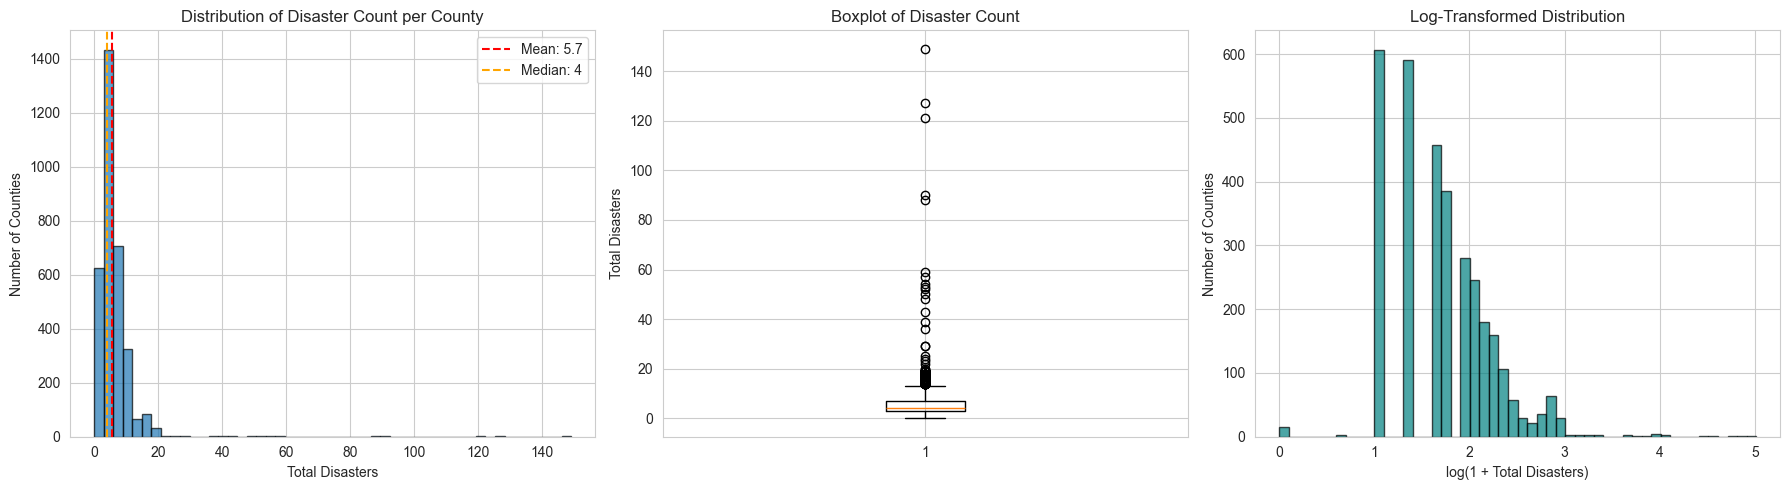

Target variable statistics:
count    3292.000000
mean        5.685905
std         6.112916
min         0.000000
25%         3.000000
50%         4.000000
75%         7.000000
max       149.000000
Name: total_disasters, dtype: float64

Skewness: 11.33
Counties with 0 disasters: 15
Counties with > 20 disasters: 21


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# histogram of total_disasters
axes[0].hist(df['total_disasters'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total Disasters')
axes[0].set_ylabel('Number of Counties')
axes[0].set_title('Distribution of Disaster Count per County')
axes[0].axvline(df['total_disasters'].mean(), color='red', linestyle='--', label=f"Mean: {df['total_disasters'].mean():.1f}")
axes[0].axvline(df['total_disasters'].median(), color='orange', linestyle='--', label=f"Median: {df['total_disasters'].median():.0f}")
axes[0].legend()

# boxplot
axes[1].boxplot(df['total_disasters'], vert=True)
axes[1].set_ylabel('Total Disasters')
axes[1].set_title('Boxplot of Disaster Count')

# log-transformed histogram (add 1 to handle zeros)
axes[2].hist(np.log1p(df['total_disasters']), bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[2].set_xlabel('log(1 + Total Disasters)')
axes[2].set_ylabel('Number of Counties')
axes[2].set_title('Log-Transformed Distribution')

plt.tight_layout()
plt.show()

print('Target variable statistics:')
print(df['total_disasters'].describe())
print(f'\nSkewness: {df["total_disasters"].skew():.2f}')
print(f'Counties with 0 disasters: {(df["total_disasters"] == 0).sum()}')
print(f'Counties with > 20 disasters: {(df["total_disasters"] > 20).sum()}')

There heavy skewedness from total disaster distribution. So applying log transformed making it look more symmetric for later modeling. Looking at the boxplot, we can see all those dot are basically outliers.

Do NOT use raw total_disasters as your regression target because the skewness will violate linear regression assumptions. Use log(1 + total_disasters) or consider Poisson regression instead.

Program activation statistics:
       ia_count  pa_count
count    3292.0    3292.0
mean        0.0       5.6
std         0.0       6.0
min         0.0       0.0
25%         0.0       3.0
50%         0.0       4.0
75%         0.0       7.0
max         0.0     149.0


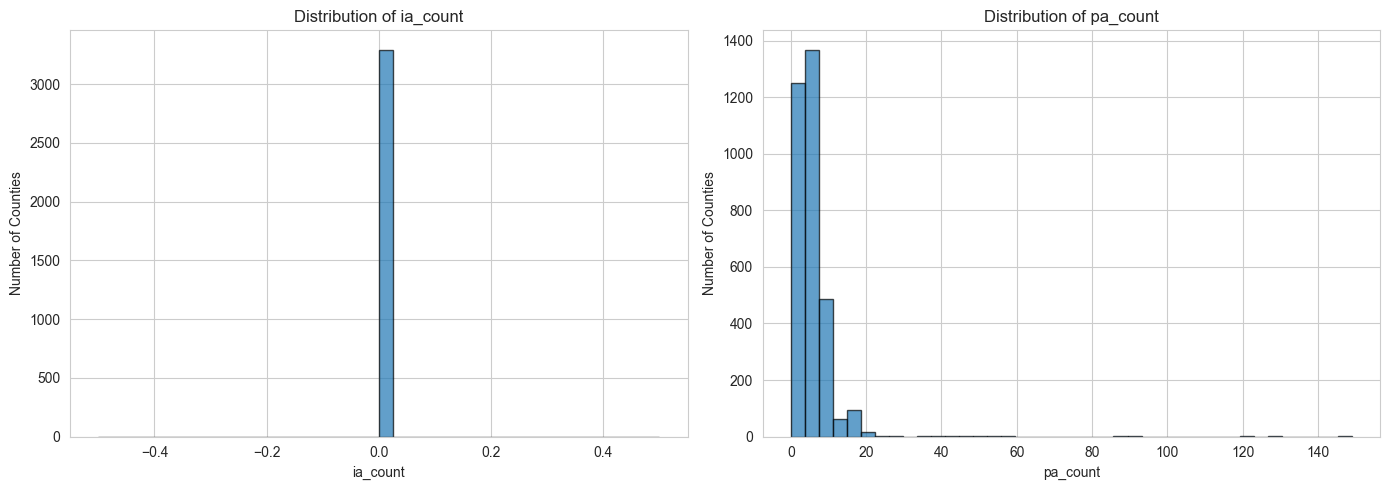

In [43]:
# program activation breakdown
program_cols = ['ia_count', 'pa_count']
program_stats = df[program_cols].describe().round(1)
print('Program activation statistics:')
print(program_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(program_cols):
    axes[i].hist(df[col], bins=40, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of Counties')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### Understanding Our Target Variable

**Right-skewed distribution:** The disaster count is heavily right-skewed (most counties have a handful of disasters, but a few have 50+). The mean (~5.7) is higher than the median (~4), confirming the skew. This is typical for count data.

**Modeling implication:** The skewness means that:
- **Linear regression** on the raw count will be pulled by outliers. A **log transformation** (`log(1 + total_disasters)`) produces a more symmetric distribution and may work better as a regression target.
- Alternatively, a **Poisson or negative binomial regression** is designed for count data and may be more appropriate than OLS.
- For **classification** (high vs. low impact), we will need to define a threshold, we would say that the median (4) is one natural choice.

**Program flags:** `pa_count` (Public Assistance) is activated far more often than `ia_count` (Individual Assistance) as we discuss earlier in data cleaning. Tought this makes sense because PA covers infrastructure repair which is declared for most disasters, while IA requires individual-level damage that not all events produce.


## Feature Engineering: Rates vs. Raw Counts

Before analyzing predictors, we need to convert raw counts to **per-capita rates**. A poverty count of 50,000 means something very different in Los Angeles (pop 10M) versus a rural county (pop 5,000). Rates normalize for population size and make counties comparable.

In [44]:
# create rate columns (avoid division by zero)
df['poverty_rate'] = np.where(
    df['total_population'] > 0,
    df['poverty_count'] / df['total_population'] * 100,
    np.nan
)

df['unemployment_rate'] = np.where(
    df['labor_force_count'] > 0,
    df['unemployment_count'] / df['labor_force_count'] * 100,
    np.nan
)

# log population (useful for modeling since population spans several orders of magnitude)
df['log_population'] = np.log1p(df['total_population'])

print('New derived features:')
print(df[['poverty_rate', 'unemployment_rate', 'log_population']].describe().round(2))

New derived features:
       poverty_rate  unemployment_rate  log_population
count       3222.00            3222.00         3222.00
mean          14.57               5.16           10.27
std            7.50               2.93            1.50
min            1.60               0.00            3.93
25%            9.83               3.44            9.31
50%           13.09               4.72           10.16
75%           17.19               6.14           11.12
max           65.57              31.99           16.11


We see that we have a extreme maximum on poverty (65 percent) and unemployment (32 percent). This suggest that our dataset contains tribal (referring to Native American reservation) counties that are econnomically unlike anything else in the data. So basicall these are not outliers from data error as they are real places with structurally different economies and our model may struggle to handle them without special treatment. So keep this in mind for later as we progress our analysis and modelling.


## Predictor Variable Distributions

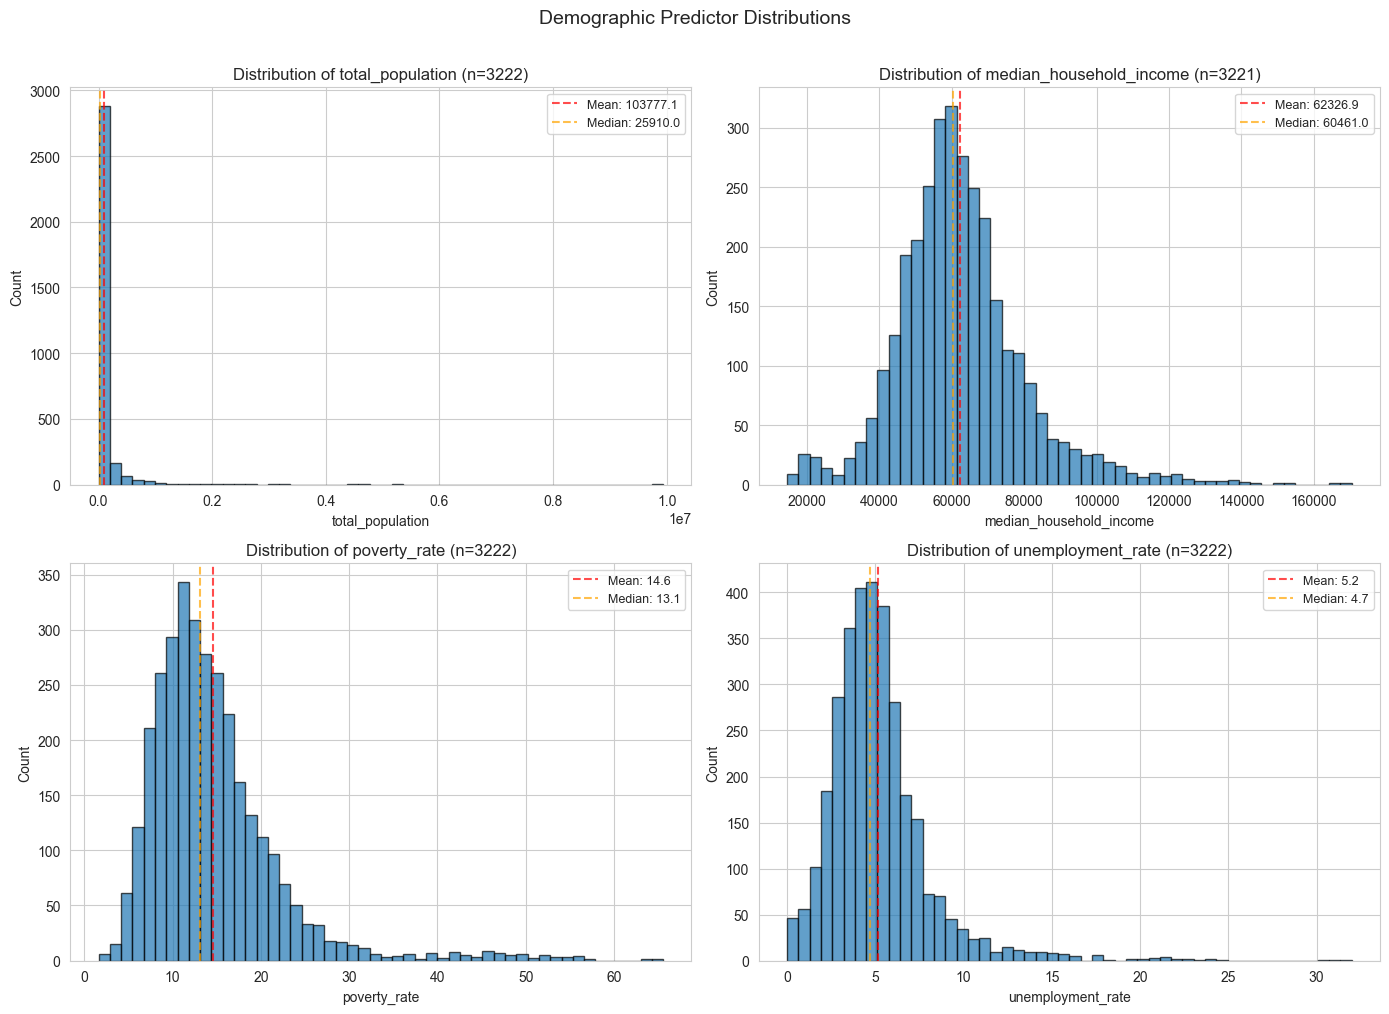

In [45]:
# demographic predictors
demo_cols = ['total_population', 'median_household_income', 'poverty_rate', 'unemployment_rate']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(demo_cols):
    ax = axes[i // 2][i % 2]
    data = df[col].dropna()
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {col} (n={len(data)})')
    ax.axvline(data.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', alpha=0.7, label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Demographic Predictor Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Population needs log transformation. Income is the cleanest variable. Poverty and unemployment are both moderately skewed with extreme outliers driven by the same structural outlier counties is something we need to flag as a model limitation.



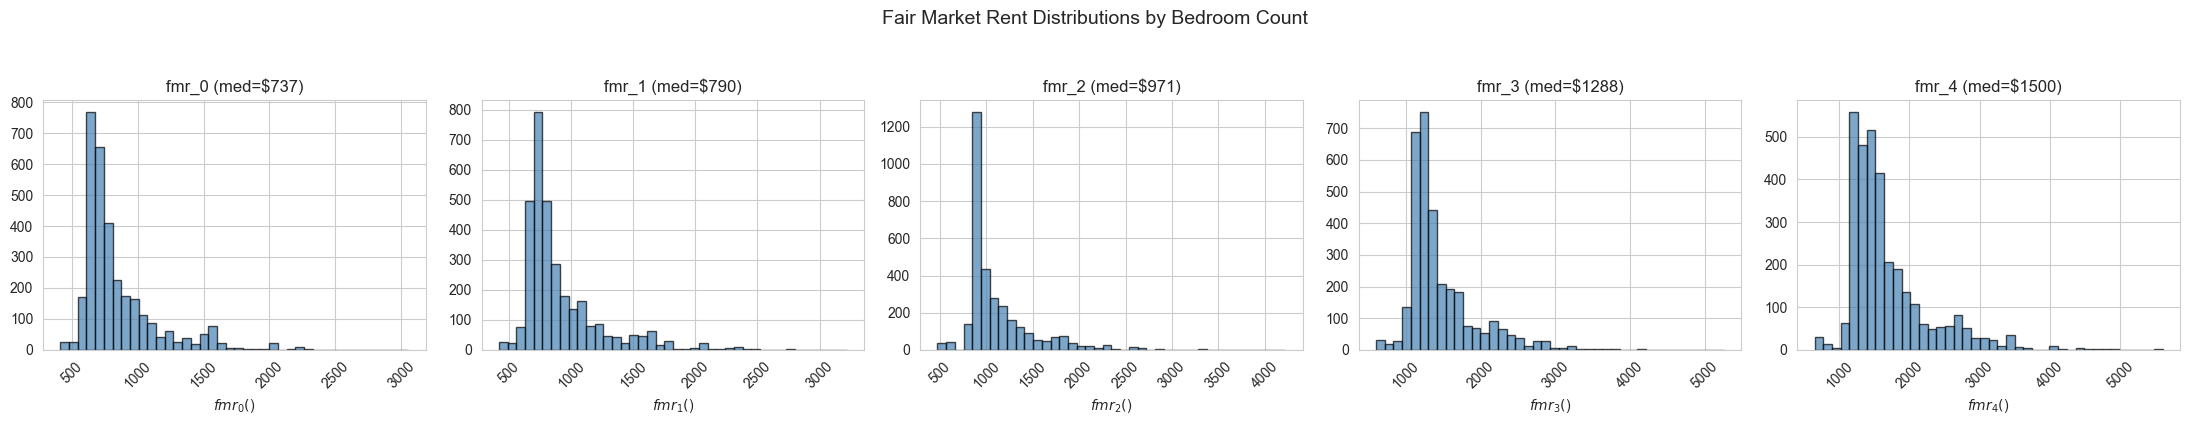

Metro counties: 1252
Non-metro counties: 1976
Missing metro flag: 64


In [46]:
# housing cost predictors (FMR 0-4 bedroom)
fmr_cols = ['fmr_0', 'fmr_1', 'fmr_2', 'fmr_3', 'fmr_4']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, col in enumerate(fmr_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_xlabel(f'${col} ($)')
    axes[i].set_title(f'{col} (med=${data.median():.0f})')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Fair Market Rent Distributions by Bedroom Count', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# metro vs non-metro
metro_counts = df['metro'].value_counts().dropna()
print(f'Metro counties: {metro_counts.get(1, 0)}')
print(f'Non-metro counties: {metro_counts.get(0, 0)}')
print(f'Missing metro flag: {df["metro"].isna().sum()}')

### Understanding Predictor Distributions

**Population:** As we investigate earlier, as expected popluation distribution with extremely right-skewed. Most counties are small (median ~26k) but a few megacounties pull the distribution far right. We will use `log_population` in models to compress this range.

**Median household income:** Roughly bell-shaped around ~$55k, with a slight right tail. A few very wealthy counties (>$120k) and Puerto Rico municipios on the low end (~$15–17k). This variable is usable as-is.

**Poverty rate:** Right-skewed with a long tail (some counties have 40–65% poverty rates — mostly Native American reservations and deep rural areas). Mean ~14.6%, which aligns with national figures.

**Unemployment rate:** Also right-skewed but less extreme. Mean ~5.2%, with outliers above 20%.

**FMR values:** All five bedroom categories show similar right-skewed shapes — most counties have rents in the $600–$1,500 range, with coastal/metro areas pulling the tail to $3,000+. The five FMR columns are highly correlated with each other (a county with expensive studios also has expensive 4-bedrooms), so we may want to use just one representative column (e.g., `fmr_2` for 2-bedroom) or take a summary measure to avoid multicollinearity.

**Metro flag:** Binary variable — useful as a categorical predictor but will need to be handled carefully in models that assume continuous inputs.

Bottom line is that we just pick fmr_2 because the plots tells us that we are looking at the same distribution five times.



## Correlation Analysis

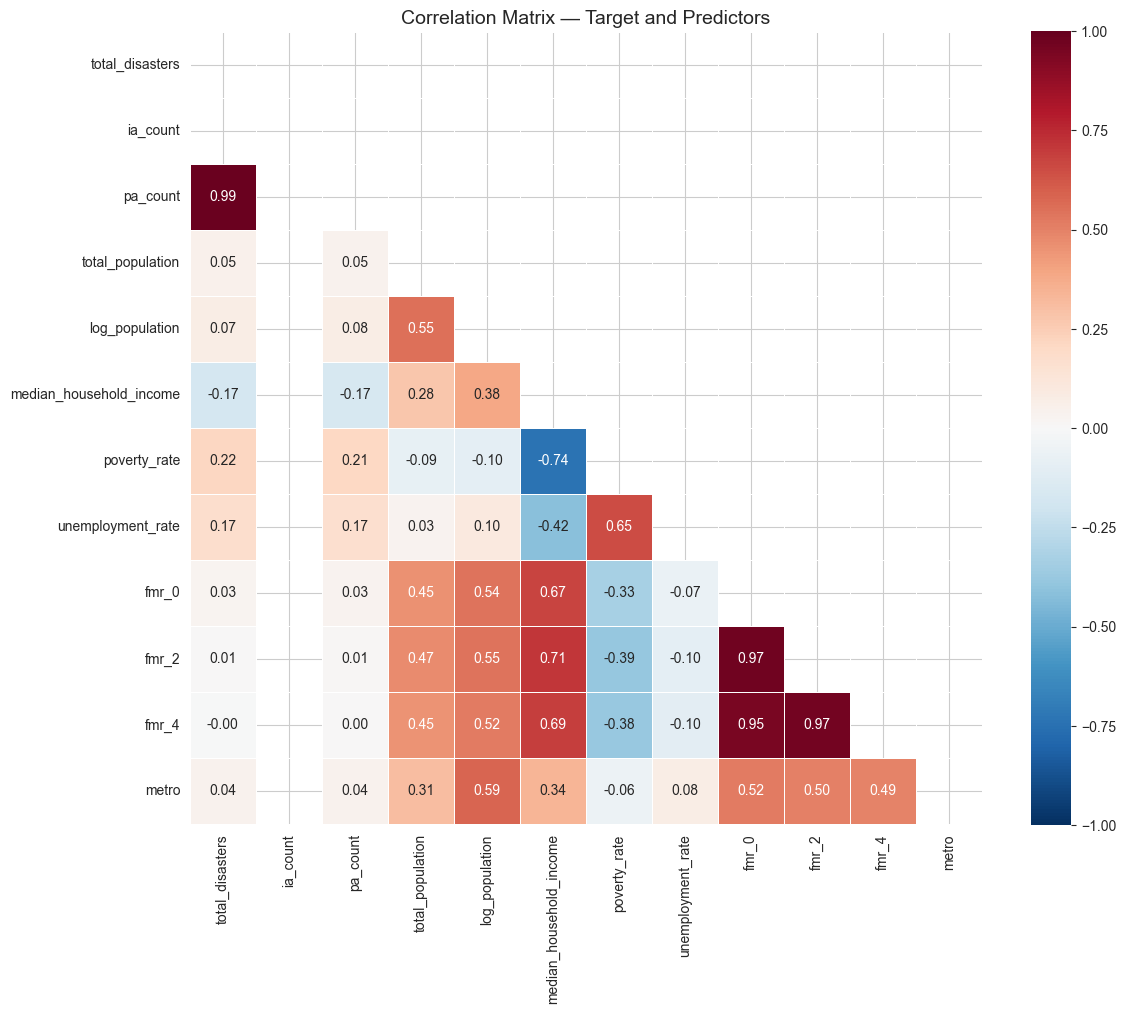

In [47]:
# select numeric columns for correlation
corr_cols = [
    'total_disasters', 'ia_count', 'pa_count',
    'total_population', 'log_population',
    'median_household_income', 'poverty_rate', 'unemployment_rate',
    'fmr_0', 'fmr_2', 'fmr_4', 'metro'
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Target and Predictors', fontsize=14)
plt.tight_layout()
plt.show()

Notice something cool, so pa_count and total_disaster is 0.99. What my understanding for this is that this is almost perfect correlation so this confirms that pa_count is essentially just total disaster but rename. But think about this, it made perfect sense intuitvely because in the database design in the begining, we did define total_disaster as COUNT(*) from county_disaster_summary VIEW. So the total_disaster is basically the count of FEMA disaster declaration rows per county. Therefore this is why pa_count correlates 0.99 with total_disaster.

Also that means this explain why correlations with demographics are so weak because total_disasters is counting how many time FEMA declared a disaster in that county, in which driven by geography (such as hurricane coast, tornado alley). Bottom lins that a poor inland county and a wealthy coastal county can have the same disaster count if they're both in hurricane paths and a wealthy coastal county will have more disasters than a poor inland county simply because of where it sits geographically.

Correlations with total_disasters:
pa_count                   0.989
poverty_rate               0.218
unemployment_rate          0.173
log_population             0.072
total_population           0.049
metro                      0.042
fmr_0                      0.027
fmr_2                      0.005
fmr_4                     -0.001
median_household_income   -0.173
ia_count                     NaN


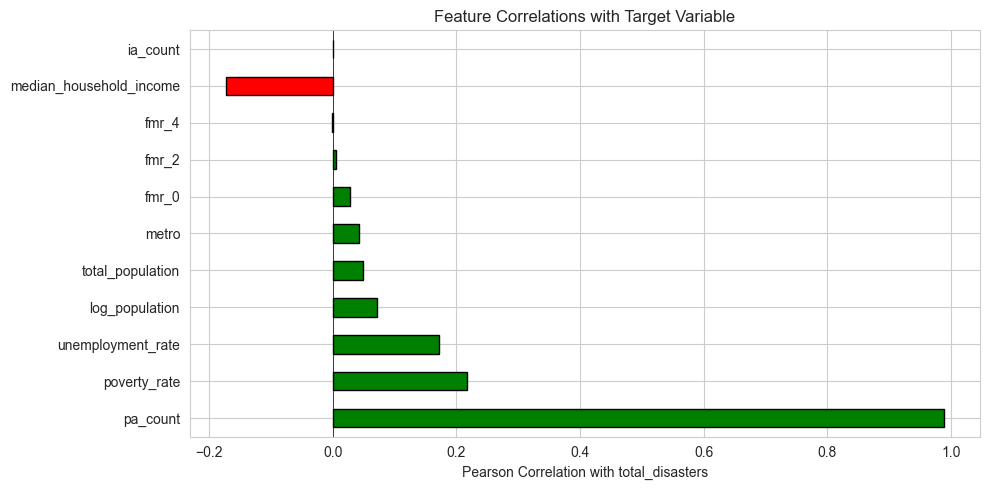

In [48]:
# correlations with the target variable specifically
target_corr = corr['total_disasters'].drop('total_disasters').sort_values(ascending=False)
print('Correlations with total_disasters:')
print(target_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if x > 0 else 'red' for x in target_corr]
target_corr.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
ax.set_xlabel('Pearson Correlation with total_disasters')
ax.set_title('Feature Correlations with Target Variable')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### Understanding Our Correlations

**What correlates with more disasters?**
- We observe the direction and strength of correlations between county characteristics and disaster frequency
- Population-related features may show positive correlation (larger counties have more area and more declarations)
- Housing and income features reveal whether wealthier or poorer counties experience more disasters

**Multicollinearity concerns:**
- The FMR columns (`fmr_0` through `fmr_4`) are very highly correlated with each other — this is expected since they all measure rental cost in the same housing market. In regression, keeping all five would inflate standard errors. We should pick one representative (e.g., `fmr_2`) or use PCA.
- `poverty_rate` and `median_household_income` are likely negatively correlated — they measure the same underlying construct (economic status) from opposite directions.
- `ia_count` and `pa_count` are subsets of `total_disasters` — they should NOT be used as predictors if `total_disasters` is the target.

**Note:** Pearson correlation only captures *linear* relationships. A variable with weak linear correlation may still have a strong non-linear relationship — we will investigate this with scatter plots next.

Also, bottom line is that, if we pesimistically project. This chart is telling you upfront that our model will struggle. Demographics and housing costs are the wrong lens for predicting disaster frequency. Geography is the missing variable here. Just to clarify, struggle is modeling does not imply it will be useless results, in fact, if a model that explain 15 percent of variance with an honest discussion at the end of why it is 15 percent is by far more valuable than stop and conclude here. So let's continue!



## Bivariate Relationships with Target

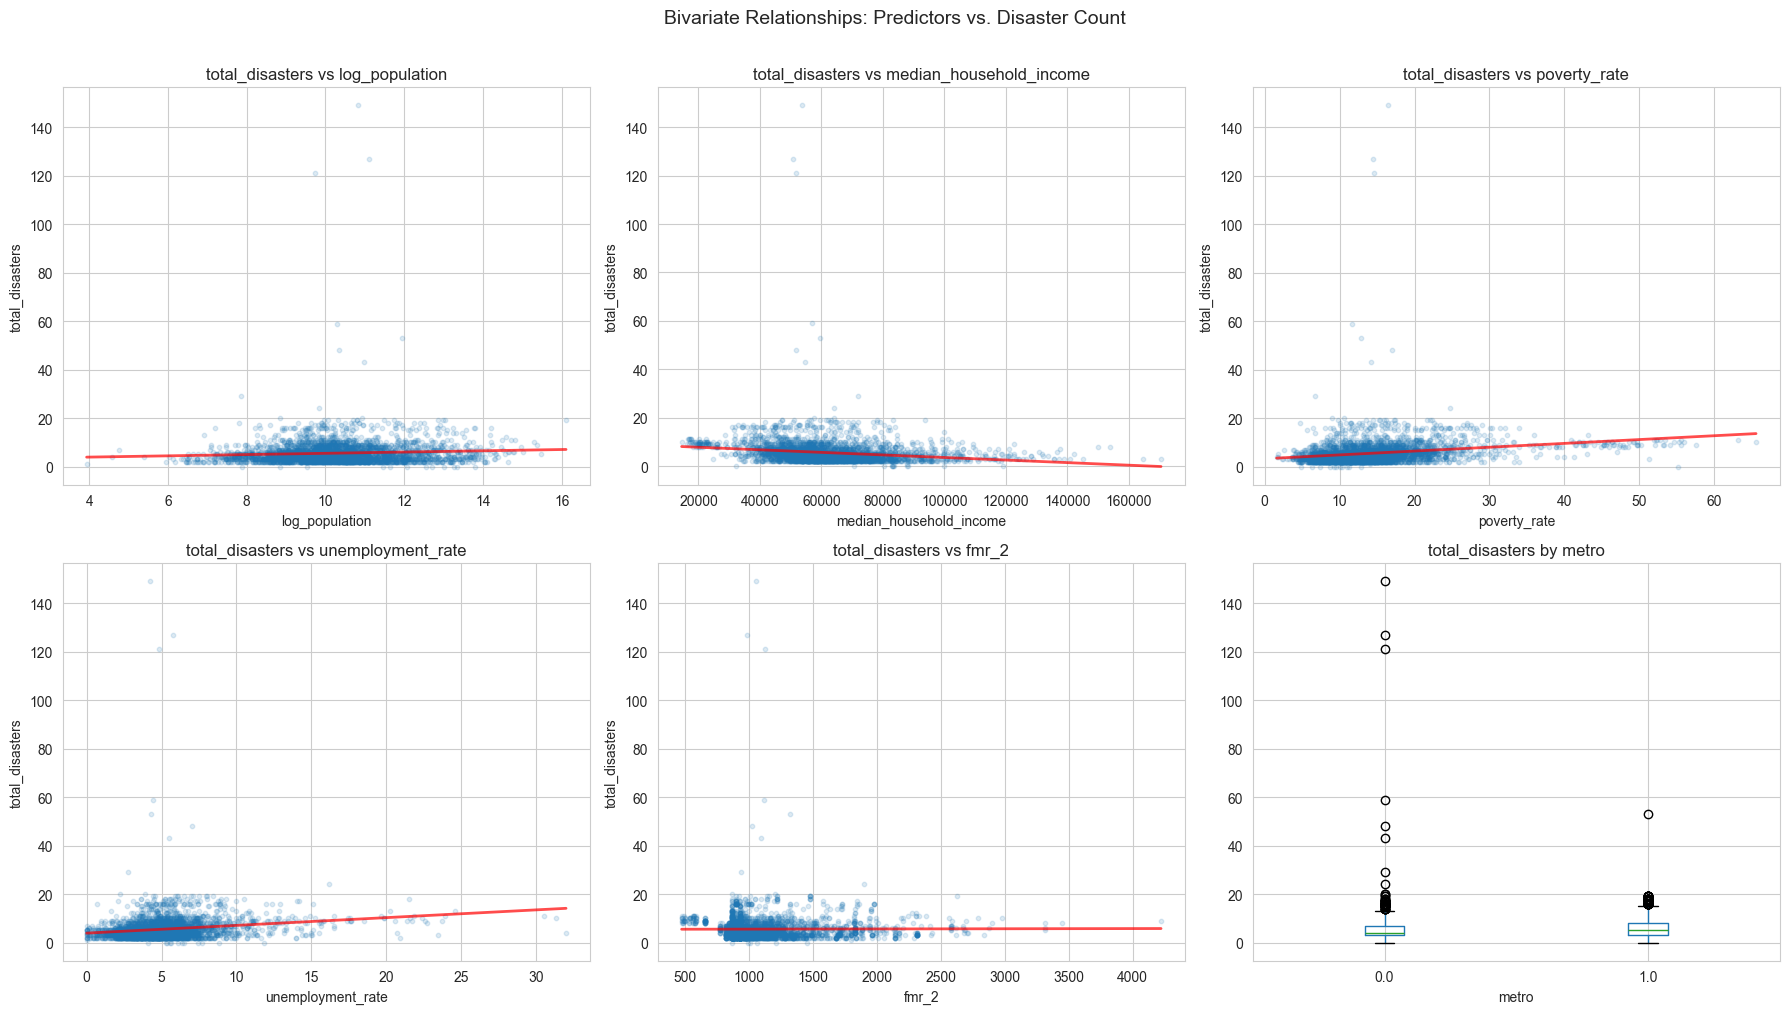

In [49]:
scatter_cols = ['log_population', 'median_household_income', 'poverty_rate', 'unemployment_rate', 'fmr_2', 'metro']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(scatter_cols):
    ax = axes[i // 3][i % 3]
    subset = df[[col, 'total_disasters']].dropna()
    if col == 'metro':
        # boxplot for binary variable
        df.boxplot(column='total_disasters', by='metro', ax=ax)
        ax.set_title(f'total_disasters by {col}')
        ax.set_xlabel(col)
        plt.sca(ax)
        plt.title(f'total_disasters by {col}')
    else:
        ax.scatter(subset[col], subset['total_disasters'], alpha=0.15, s=10)
        ax.set_xlabel(col)
        ax.set_ylabel('total_disasters')
        ax.set_title(f'total_disasters vs {col}')
        # add trend line
        z = np.polyfit(subset[col], subset['total_disasters'], 1)
        x_line = np.linspace(subset[col].min(), subset[col].max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), color='red', linewidth=2, alpha=0.7)

plt.suptitle('Bivariate Relationships: Predictors vs. Disaster Count', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Understanding Our Bivariate Relationships

These scatter plots show the relationship between each predictor and the disaster count. The red trend lines show the linear fit.

**Key patterns to observe:**
- **Population vs. disasters:** Larger counties likely have more declarations simply because they cover more geographic area and population. This is a potential confound — are we predicting *vulnerability* or just *size*?
- **Income and poverty vs. disasters:** If lower-income counties have more disasters, that suggests socioeconomic vulnerability. If there is no clear pattern, disasters may be driven more by geography (hurricane coast, tornado alley) than demographics.
- **Metro vs. non-metro:** A comparison of disaster frequency across metro and non-metro counties reveals whether urban or rural areas are more affected.
- **FMR vs. disasters:** Housing costs proxy for urbanization and regional wealth — their relationship with disaster counts may be confounded by geography.

**Important caveat:** These are *observational* patterns. Correlation between poverty and disasters does not mean poverty *causes* disasters . Again both may be driven by geographic location (e.g., Gulf Coast counties are both lower-income and hurricane-prone).

## Geographic Patterns — State-Level Summary

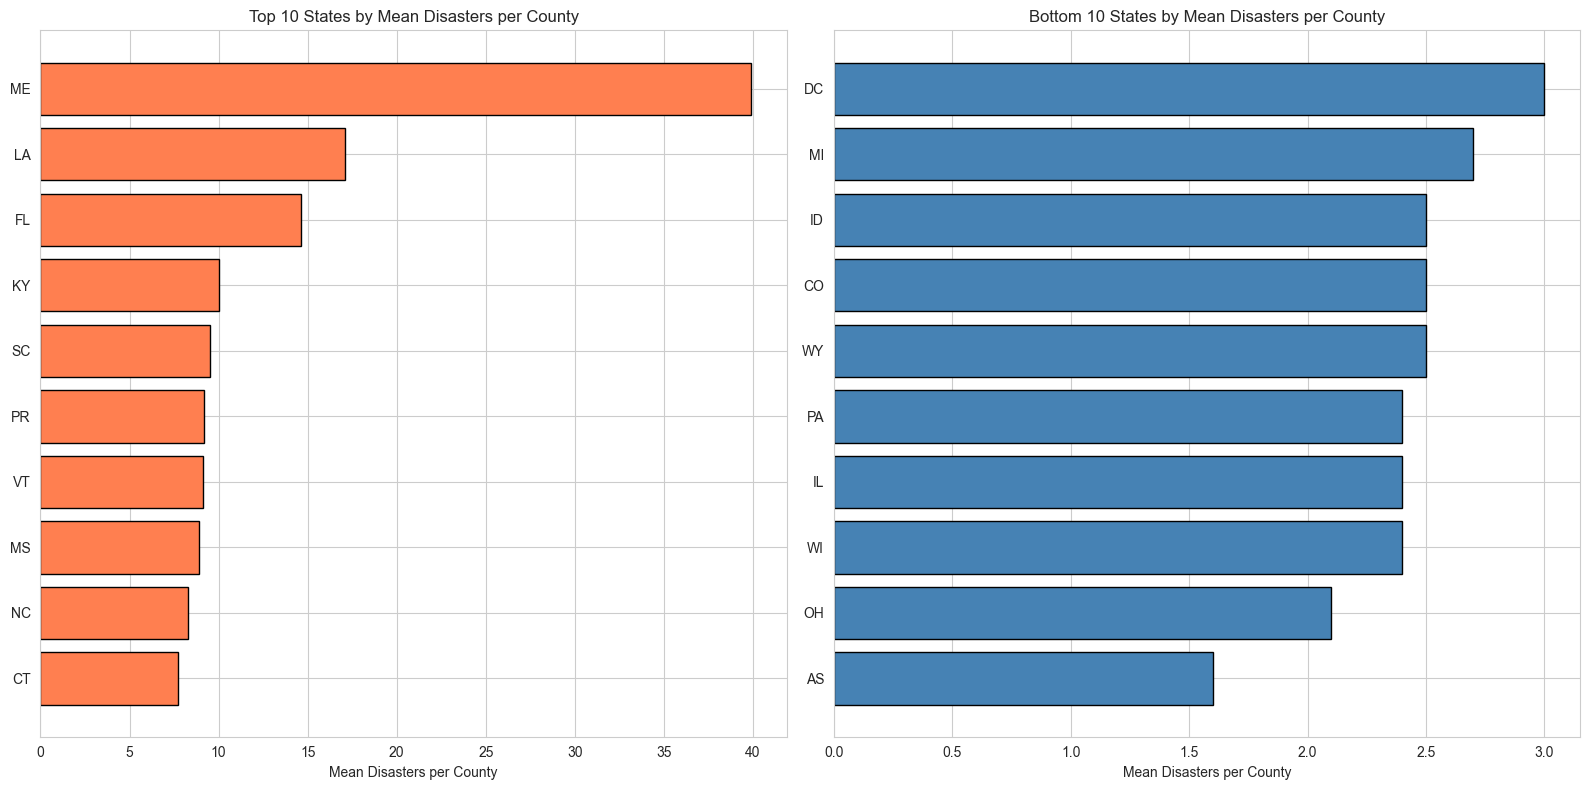

Top 10 states by mean disasters per county:
            n_counties  total_disasters  mean_disasters
state_abbr                                             
ME                  17              678            39.9
LA                  65             1114            17.1
FL                  68              990            14.6
KY                 120             1206            10.0
SC                  47              446             9.5
PR                  78              719             9.2
VT                  14              127             9.1
MS                  83              737             8.9
NC                 101              837             8.3
CT                   9               69             7.7


In [50]:
# state-level disaster summary
state_summary = df.groupby('state_abbr').agg(
    n_counties=('fips', 'count'),
    total_disasters=('total_disasters', 'sum'),
    mean_disasters=('total_disasters', 'mean'),
    median_income=('median_household_income', 'median'),
    mean_poverty_rate=('poverty_rate', 'mean')
).round(1)

state_summary = state_summary.sort_values('mean_disasters', ascending=False)

# top and bottom 10 states by mean disasters per county
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top10 = state_summary.head(10)
axes[0].barh(top10.index, top10['mean_disasters'], color='coral', edgecolor='black')
axes[0].set_xlabel('Mean Disasters per County')
axes[0].set_title('Top 10 States by Mean Disasters per County')
axes[0].invert_yaxis()

bot10 = state_summary.tail(10)
axes[1].barh(bot10.index, bot10['mean_disasters'], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Mean Disasters per County')
axes[1].set_title('Bottom 10 States by Mean Disasters per County')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('Top 10 states by mean disasters per county:')
print(top10[['n_counties', 'total_disasters', 'mean_disasters']].to_string())

### Understandin Our Geographic Patterns

The state-level breakdown reveals which regions drive the most disaster declarations. States in hurricane corridors, tornado alley, and wildfire-prone Western regions are expected to dominate the top of the list.

**Why this matters for modeling:** If geography is the dominant predictor of disaster frequency, then our demographic and housing features may have limited *additional* explanatory power once location is accounted for. We may need to either:
1. Include state fixed effects (dummy variables) to control for geography, then see if demographics still matter
2. Or explicitly acknowledge that our model partially predicts *location* rather than *vulnerability*

But yes, bottom is that is we discovered the strongest evidence that state fixed effects are necessary in your model. Without controlling for state/geography, our demographic predictors are fighting against a signal they can never explain.



## 9. FMR Multicollinearity Check

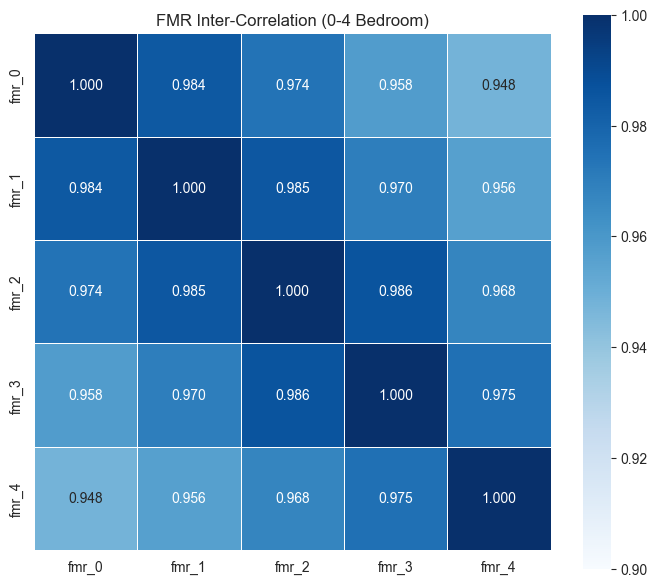

All FMR pairwise correlations are above 0.9.


In [51]:
fmr_cols = ['fmr_0', 'fmr_1', 'fmr_2', 'fmr_3', 'fmr_4']
fmr_corr = df[fmr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(fmr_corr, annot=True, fmt='.3f', cmap='Blues', square=True,
            vmin=0.9, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title('FMR Inter-Correlation (0-4 Bedroom)')
plt.tight_layout()
plt.show()

print('All FMR pairwise correlations are above 0.9.')


### Interpretation — FMR Multicollinearity

Looking at the graph above, so all five FMR columns are correlated above 0.94 with each other. We expected this and
by design: during our ETL pipeline, we resolved HUD's duplicate county entries
such that a single county FIPS mapped to multiple towns or sub-areas by applying a
**population-weighted average**, collapsing each bedroom-size FMR into one unified
county-level value. The result is that all five columns already represent the same
underlying construct: the overall housing market cost level of that county, scaled
by bedroom count. Including all five in a regression model would cause severe
**multicollinearity** thereby inflated variance on coefficient estimates and unstable model
fits without adding any new information beyond what a single column already captures.

**Decision:** We use `fmr_2` (2-bedroom Fair Market Rent) as the single housing cost
representative. Because the population-weighted averaging already made each FMR column
a clean, county-level signal, any of the five would be equally valid. We choose `fmr_2`
because the 2-bedroom unit is HUD's own primary published benchmark for housing
affordability policy and the most widely cited FMR in housing research, making our
results directly interpretable against existing literature.



## 10. Summary of EDA Findings

### Proposed Feature Set for Modeling

Based on this EDA, our candidate predictors are:

1. `log_population`: log-transformed total population
2. `median_household_income`: economic capacity
3. `poverty_rate`: economic vulnerability (derived)
4. `unemployment_rate`: labor market health (derived)
5. `fmr_2`: housing cost proxy (2-bedroom FMR)
6. `metro`: urban/rural classification

### Next Steps

1. **Decide on target formulation:** regression on `log(1 + total_disasters)` vs. classification (high/low impact threshold)
3. **Build baseline models:** OLS regression and logistic regression
4. **Evaluate tree-based models:** Random Forest, XGBoost for non-linear patterns
5. **Assess whether state-level controls are needed** to separate geography from demographics

Bottom line is that, in the next step, modeling, we want to investigate whether if model sees Louisiana vs Idaho, it only sees their demographics. It can't see that Louisiana sits on the Gulf Coast hurricane path and Idaho doesn't.

These predictors we proposed, we might think it explain total_disaster (poverty_rate, income, unemployment_rate, fmr_2, metro, log_population), however, none of these tell the model WHERE the county is geographically. This is our hypothesis and we will examine this in the next step, modeling.

# Reference
- U.S. Census Bureau. (2023). American Community Survey 5-Year Estimates (2019–2023). U.S. Department of Commerce. Retrieved from https://www.census.gov/programs-surveys/acs

- Federal Register. (2022). Change to county-equivalents in the state of Connecticut,
  87 FR 34235. https://www.federalregister.gov/documents/2022/06/06/2022-12063/

- U.S. Census Bureau. (2023a). Change to county-equivalents in the state of Connecticut
  for 2022 ACS (User Note 2023-01).
  https://www.census.gov/programs-surveys/acs/technical-documentation/user-notes/2023-01.html

- U.S. Census Bureau. (2023b). American Community Survey 5-Year Estimates (2019–2023).
  U.S. Department of Commerce.
  https://www.census.gov/programs-surveys/acs

- U.S. Department of Housing and Urban Development. (2023). Fair Market Rents.
  HUD USER. https://www.huduser.gov/portal/datasets/fmr.html
